**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Luis Felipe García Domínguez

## Práctica 1: Análisis Exploratorio de Datos
### Estadística de Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS 2025) - INEGI

Este notebook presenta un análisis exploratorio estructurado sobre los accidentes viales en México a partir de la estadística oficial **ATUS 2025**, recopilada y publicada por el **Instituto Nacional de Estadística y Geografía (INEGI)**.

### Contexto y procedencia del conjunto de datos

- **¿Qué mide?**  
  La siniestralidad del transporte terrestre en vialidades no federales (zonas urbanas y suburbanas) a nivel nacional, estatal y municipal. Cuantifica los incidentes viales, sus causas presuntas, los tipos de percance (colisiones, atropellamientos, volcaduras, etc.), las características de los conductores y vehículos involucrados, las condiciones de la vía y el saldo de víctimas (lesionados y personas fallecidas en el lugar del hecho, clasificadas por rol: conductor, pasajero, peatón, ciclista u otro).

- **¿Quién lo recolectó?**  
  El **Instituto Nacional de Estadística y Geografía (INEGI)**, a través de la Dirección General Adjunta de Registros Administrativos Económicos y la Dirección de Estadísticas Económicas de Registros Administrativos (DEERA).

- **¿Cuándo se recolectó?**  
  El levantamiento de incidentes se realiza de forma continua durante el año. Los datos corresponden a los percances ocurridos del **1 de enero al 31 de diciembre de 2025** (cifras anuales definitivas publicadas por el INEGI en julio de 2026).

- **¿Cuál es la unidad de observación?**  
  Cada **accidente de tránsito terrestre** ocurrido en zonas urbanas y suburbanas dentro del territorio nacional, registrado formalmente por las corporaciones de seguridad y vialidad locales.

- **Enlaces de procedencia y metadatos:**  
  - Fuente oficial: [INEGI — Accidentes de Tránsito Terrestre](https://www.inegi.org.mx/programas/accidentes/#datos_abiertos)
  - Ficha metodológica y descripción del estudio: [Catálogo Nacional de Metadatos (Estudio 1115)](https://www.inegi.org.mx/rnm/index.php/catalog/1115/study-description)
  - Diccionario de datos: [Catálogo de variables ATUS 1997-2024](https://www.inegi.org.mx/rnm/index.php/catalog/1115/data-dictionary/F1?file_name=ATUS)
  - Licencia de uso: [Términos de libre uso de información del INEGI](https://www.inegi.org.mx/inegi/terminos.html)

---

### Preparación

Cargamos las librerías básicas requeridas para el análisis exploratorio y la visualización: **pandas**, **numpy**, **matplotlib** y **seaborn**.  
Así mismo, cargamos **warnings** para mantener la salida de código limpia (libre de advertencias no relevantes).

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)

numpy      2.5.3
pandas     3.0.5
matplotlib 3.11.2
seaborn    0.13.2


Definimos la paleta de colores.

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

---

### Los datos

El conjunto de datos principal corresponde al archivo `atus_anual_2025.csv`, el cual consolida los registros de accidentes de tránsito en zonas urbanas y suburbanas de México durante el año 2025.

La gran mayoría de las columnas ya vienen codificadas en texto descriptivo legible (`TIPACCID`, `CAUSAACCI`, `SEXO`, `ALIENTO`, `CLASACC`, etc.). Sin embargo, considero que la columna de entidad se entiende mejor si se representa por su nombre oficial en lugar de su código numérico (`CVE_ENT`). Para esto, utilizamos el catálogo `tc_entidad.csv` (disponible como parte del dataset del INEGI, entre otros catálogos), para mapear los valores correspondientes.

Es importante mencionar que, en apego al catálogo `tc_edad.csv` y al diccionario de datos oficial del INEGI, se identificó un caso especial en los valores de `ID_EDAD`. Esta variable utiliza números del 12 al 98 para registrar la edad cumplida del conductor presunto responsable, pero reserva dos códigos numéricos especiales:

- **`0`**: Indica *"Se ignora porque se fugó"* (el conductor abandonó el lugar del siniestro tras el percance).
- **`99`**: Indica *"No especificado / Se ignora"* (la edad no fue reportada o no fue posible determinarla).

Mapeamos los nombres de los estados y creamos el crudo.

In [3]:
# Ruta a los datos
RUTA_BASE = Path("..") if (Path("..") / "data").exists() else Path(".")
RUTA_DATOS = RUTA_BASE / "data" / "atus_anual_2025.csv"
RUTA_ENTIDADES = RUTA_BASE / "data" / "tc_entidad.csv"

# Mapeo del catálogo de entidades para obtener el nombre oficial del estado
cat_entidades = pd.read_csv(RUTA_ENTIDADES)
dicc_entidades = dict(zip(cat_entidades["CVE_ENT"].astype(int), cat_entidades["NOM_ENTIDAD"]))

# Carga del conjunto de datos crudo
crudo = pd.read_csv(RUTA_DATOS)
crudo["ENTIDAD"] = crudo["CVE_ENT"].map(dicc_entidades)

print(f"{crudo.shape[0]:,} registros × {crudo.shape[1]} atributos")
crudo.head(3)

380,391 registros × 47 atributos


,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,CAMPASAJ,MICROBUS,PASCAMION,OMNIBUS,TRANVIA,CAMIONETA,CAMION,TRACTOR,FERROCARRI,MOTOCICLET,BICICLETA,OTROVEHIC,CAUSAACCI,CAPAROD,SEXO,ALIENTO,CINTURON,ID_EDAD,CONDMUERTO,CONDHERIDO,PASAMUERTO,PASAHERIDO,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS,ENTIDAD
0,Municipal,1001,1,1,2025,1,3,30,1,Miércoles,Accidente en no intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,Se ignora,Se ignora,29,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,Aguascalientes
1,Municipal,1001,1,1,2025,1,8,15,1,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,0,0,0,0,0,0,1,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,Sí,Se ignora,32,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,Aguascalientes
2,Municipal,1001,1,1,2025,1,8,35,1,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Mujer,Sí,Se ignora,25,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,Aguascalientes


### Verificación inicial

In [4]:
n_filas, n_columnas = crudo.shape
n_numericas = crudo.select_dtypes(include="number").shape[1]
n_no_numericas = crudo.select_dtypes(exclude="number").shape[1]

print(f"Registros:               {n_filas:>5}")
print(f"Atributos:               {n_columnas:>5}")
print(f"  numéricos:             {n_numericas:>5}")
print(f"  no numéricos:          {n_no_numericas:>5}")
print(f"Duplicados exactos:      {crudo.duplicated().sum():>5}")
print(f"Registros con faltantes: {crudo.isna().any(axis=1).sum():>5}")

Registros:               380391
Atributos:                  47
  numéricos:                34
  no numéricos:             13


Duplicados exactos:        748
Registros con faltantes:     0


Y comprobamos el número de apariciones de los casos especiales de `ID_EDAD`.

In [5]:
conteo_fuga = (crudo['ID_EDAD'] == 0).sum()
conteo_ignora = (crudo['ID_EDAD'] == 99).sum()
total_registros = len(crudo)

print(f"Conductor se fugó (código 0)     : {conteo_fuga:>6,} ({conteo_fuga / total_registros * 100:.2f} %)")
print(f"Edad no especificada (código 99) : {conteo_ignora:>6,} ({conteo_ignora / total_registros * 100:.2f} %)")
print(f"Total de casos especiales        : {conteo_fuga + conteo_ignora:>6,} ({(conteo_fuga + conteo_ignora) / total_registros * 100:.2f} %)")
print(f"Edades válidas (12 a 98 años)    : {total_registros - (conteo_fuga + conteo_ignora):>6,} ({(total_registros - (conteo_fuga + conteo_ignora)) / total_registros * 100:.2f} %)")

Conductor se fugó (código 0)     : 34,919 (9.18 %)
Edad no especificada (código 99) : 53,152 (13.97 %)
Total de casos especiales        : 88,071 (23.15 %)
Edades válidas (12 a 98 años)    : 292,320 (76.85 %)


Se observa que casi una cuarta parte de nuestros datos consiste de los casos especiales (0 y 99), por lo que estos valores se tendrán presentes para evitar distorsionar cualquier cálculo de edad promedio, distribución, etc.

### Subconjunto de trabajo

El archivo crudo contiene 47 columnas (incluyendo el nombre de la entidad), muchas de las cuales corresponden a subdivisiones específicas de vehículos o identificadores auxiliares. 

Seleccionamos un subconjunto enfocado y representativo para el estudio de los patrones de accidentalidad, el perfil del conductor y la gravedad del percance:
- **Espacio-temporales:** `MES`, `ID_HORA`, `DIASEMANA`, `URBANA`, `SUBURBANA`, `ENTIDAD`.
- **Circunstancias del accidente:** `TIPACCID`, `CAUSAACCI`, `CAPAROD`.
- **Características del conductor:** `SEXO`, `ALIENTO`, `CINTURON`, `ID_EDAD`.
- **Víctimas y severidad (Variable objetivo):** Desglose completo de personas fallecidas y lesionadas (conductores, pasajeros, peatones, ciclistas y otros), junto con `CLASACC` (que clasifica el evento en *Sólo daños*, *No fatal* o *Fatal*).

In [6]:
COLUMNAS_TEMPORALES_ESPACIALES = [
    "MES", "ID_HORA", "DIASEMANA", "URBANA", "SUBURBANA", "ENTIDAD"
]

COLUMNAS_CIRCUNSTANCIAS = [
    "TIPACCID", "CAUSAACCI", "CAPAROD"
]

COLUMNAS_CONDUCTOR = [
    "SEXO", "ALIENTO", "CINTURON", "ID_EDAD"
]

COLUMNAS_MUERTOS = [
    "CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"
]

COLUMNAS_HERIDOS = [
    "CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"
]

COLUMNAS_VICTIMAS_GRAVEDAD = COLUMNAS_MUERTOS + COLUMNAS_HERIDOS + ["CLASACC"]

COLUMNAS_TRABAJO = (
    COLUMNAS_TEMPORALES_ESPACIALES +
    COLUMNAS_CIRCUNSTANCIAS +
    COLUMNAS_CONDUCTOR +
    COLUMNAS_VICTIMAS_GRAVEDAD
)

accidentes = crudo[COLUMNAS_TRABAJO].copy()
accidentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 380391 entries, 0 to 380390
Data columns (total 26 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   MES         380391 non-null  int64
 1   ID_HORA     380391 non-null  int64
 2   DIASEMANA   380391 non-null  str  
 3   URBANA      380391 non-null  str  
 4   SUBURBANA   380391 non-null  str  
 5   ENTIDAD     380391 non-null  str  
 6   TIPACCID    380391 non-null  str  
 7   CAUSAACCI   380391 non-null  str  
 8   CAPAROD     380391 non-null  str  
 9   SEXO        380391 non-null  str  
 10  ALIENTO     380391 non-null  str  
 11  CINTURON    380391 non-null  str  
 12  ID_EDAD     380391 non-null  int64
 13  CONDMUERTO  380391 non-null  int64
 14  PASAMUERTO  380391 non-null  int64
 15  PEATMUERTO  380391 non-null  int64
 16  CICLMUERTO  380391 non-null  int64
 17  OTROMUERTO  380391 non-null  int64
 18  NEMUERTO    380391 non-null  int64
 19  CONDHERIDO  380391 non-null  int64
 20  PASAHERIDO  380

Los nombres de columna se conservan en mayúsculas, tal como vienen en el diccionario de datos oficial del INEGI.

### Comprobación de requisitos de la práctica

Comprobamos programáticamente sobre nuestro subconjunto de trabajo las condiciones indicadas para el dataset.

In [7]:
n_registros, n_atributos = accidentes.shape
cols_num = accidentes.select_dtypes(include="number").columns.tolist()
cols_cat = accidentes.select_dtypes(exclude="number").columns.tolist()

hay_duplicados = accidentes.duplicated().sum() > 0
hay_codigos_especiales = accidentes["ID_EDAD"].isin([0, 99]).any()

requisitos = [
    ("Al menos 500 registros", n_registros >= 500, f"{n_registros:,} registros"),
    ("Al menos 10 atributos", n_atributos >= 10, f"{n_atributos} atributos seleccionados"),
    ("Al menos 2 atributos numéricos", len(cols_num) >= 2, f"{len(cols_num)} atributos numéricos"),
    ("Al menos 2 atributos categóricos", len(cols_cat) >= 2, f"{len(cols_cat)} atributos categóricos"),
    ("Variable objetivo identificada", True, "CLASACC (Sólo daños, No fatal, Fatal)"),
    ("Datos reales con anomalías/fuera de rango", hay_duplicados and hay_codigos_especiales, 
     "748 duplicados exactos y 88,071 casos especiales en ID_EDAD (0=fuga, 99=ignorado)"),
    ("Procedencia verificable", True, "INEGI - ATUS 2025 (cifras definitivas)"),
    ("No didáctico / Sin solución trivial", True, "Estadística oficial de siniestralidad vial en zonas urbanas y suburbanas")
]

print("=" * 85)
print(f'{"VERIFICACIÓN DE REQUISITOS DEL DATASET":^85}')
print("=" * 85)
for nombre, cumple, detalle in requisitos:
    marca = "[✔] CUMPLE" if cumple else "[✘] NO CUMPLE"
    print(f"{marca:<12} | {nombre:<40} | {detalle}")
print("=" * 85)

                       VERIFICACIÓN DE REQUISITOS DEL DATASET                        
[✔] CUMPLE   | Al menos 500 registros                   | 380,391 registros
[✔] CUMPLE   | Al menos 10 atributos                    | 26 atributos seleccionados
[✔] CUMPLE   | Al menos 2 atributos numéricos           | 15 atributos numéricos
[✔] CUMPLE   | Al menos 2 atributos categóricos         | 11 atributos categóricos
[✔] CUMPLE   | Variable objetivo identificada           | CLASACC (Sólo daños, No fatal, Fatal)
[✔] CUMPLE   | Datos reales con anomalías/fuera de rango | 748 duplicados exactos y 88,071 casos especiales en ID_EDAD (0=fuga, 99=ignorado)
[✔] CUMPLE   | Procedencia verificable                  | INEGI - ATUS 2025 (cifras definitivas)
[✔] CUMPLE   | No didáctico / Sin solución trivial      | Estadística oficial de siniestralidad vial en zonas urbanas y suburbanas


---

## 1. Calidad de los datos

Esta sección revisa cuatro aspectos:
- **Valores faltantes:** cuántos hay, en qué columnas, y la distinción entre nulos técnicos/
ausencias por omisión.
- **Registros duplicados:** si hay filas repetidas que puedan sesgar conteos.
- **Valores imposibles o fuera de rango:** códigos especiales de captura que distorsionan resúmenes numéricos.
- **Cardinalidad y codificación:** si las categorías tienen sentido o si hay inconsistencias en las respuestas.

### Valores faltantes

Se verifica la presencia de valores nulos (`Nan`), pero además se considera que en esta base de datos una de las formas de ausencia de información se ha codificado como categorías de no respuesta (*"Se ignora"*, *"Se fugó"*, *"No especificado"*).

Valores nulos técnicos (NaN) por columna:
No hay valores nulos técnicos en ninguna columna (0.0 %).


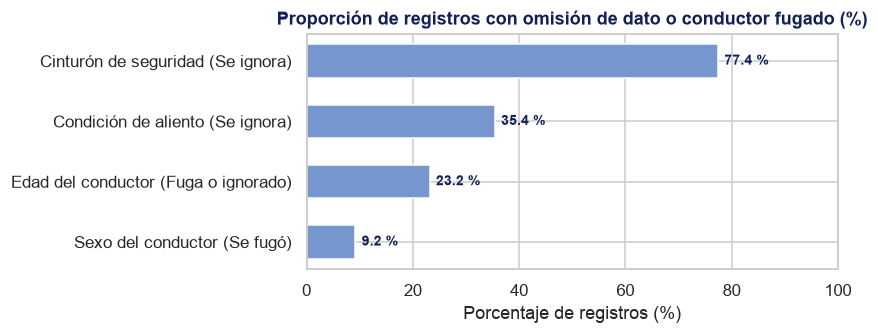

In [8]:
# 1. Verificación de nulos (NaN)
nulos_tecnicos = accidentes.isna().sum()
print("Valores nulos técnicos (NaN) por columna:")
print(nulos_tecnicos[nulos_tecnicos > 0] if (nulos_tecnicos > 0).any() else "No hay valores nulos técnicos en ninguna columna (0.0 %).")

# 2. Identificación de ausencias semánticas o falta de dato
ausencias_semanticas = pd.Series({
    "Cinturón de seguridad (Se ignora)": (accidentes["CINTURON"] == "Se ignora").mean() * 100,
    "Condición de aliento (Se ignora)": (accidentes["ALIENTO"] == "Se ignora").mean() * 100,
    "Edad del conductor (Fuga o ignorado)": accidentes["ID_EDAD"].isin([0, 99]).mean() * 100,
    "Sexo del conductor (Se fugó)": (accidentes["SEXO"] == "Se fugó").mean() * 100
}).sort_values(ascending=True)

# Visualización de ausencias
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(ausencias_semanticas.index, ausencias_semanticas.values, color=AZUL, height=0.55)
ax.set_xlim(0, 100)
ax.set_title("Proporción de registros con omisión de dato o conductor fugado (%)")
ax.set_xlabel("Porcentaje de registros (%)")

for i, v in enumerate(ausencias_semanticas.values):
    ax.text(v + 1.2, i, f"{v:.1f} %", va="center", fontsize=9, fontweight="bold", color=AZUL_OSCURO)

plt.tight_layout()
plt.show()

**Lectura.** Aunque técnicamente no existe ningún valor nulo (`NaN`) en la tabla debido a que el INEGI valida la estructura completa de campos, existe una notable ausencia semántica:
- En el **77.4 %** de los accidentes se ignora si el conductor usaba cinturón de seguridad, por lo que el uso de esta variable para comentar sobre la efectividad de este tipo de medidas de seguridad es limitado.
- En el **35.4 %** de los casos se ignora el estado de alcoholemia, lo que indica que a más de un tercio de los conductores no se les practicó o registró examen toxicológico.
- En el **23.2 %** no se dispone de la edad del conductor (dividido entre fugas y no especificados), y en el **9.2 %** se desconoce el sexo del conductor debido a que se dio a la fuga de forma inmediata.

### Registros duplicados

Revisamos la presencia de filas repetidas tanto en la tabla original completa (`crudo`) como en el subconjunto de trabajo (`accidentes`).

In [9]:
duplicados_crudo = crudo.duplicated().sum()
duplicados_trabajo = accidentes.duplicated().sum()

print(f"Duplicados exactos en el conjunto crudo (47 columnas)    : {duplicados_crudo:>6,}")
print(f"Duplicados exactos en subconjunto trabajo (18 columnas)  : {duplicados_trabajo:>6,}")

Duplicados exactos en el conjunto crudo (47 columnas)    :    748
Duplicados exactos en subconjunto trabajo (18 columnas)  : 16,973


**Lectura.**  

En la tabla cruda original existen **748 filas exactamente duplicadas** en todas sus 47 columnas (mismo estado, municipio, minuto, vehículos involucrados y víctimas). Esto sugiere que existe doble captura por parte del origen de la información, o una deficiencia al registrar datos particulares del accidente, como el minuto específico.

Por otra parte, los registros repetidos en el subconjunto de trabajo representan accidentes distintos que comparten los mismos atributos (por ejemplo, dos choques de sólo daños ocurridos en la misma entidad durante la misma hora, ya que en este subconjunto se optó por descartar parámetros como `ID_MINUTO`, que bien podría aportar más granularidad, pero lo consideré innecesario para efectos de esta exploración).

### Valores imposibles y fuera de rango

Examinamos dos aspectos:
1. **Consistencia de gravedad:** Que no existan accidentes clasificados como *Sólo daños* con víctimas fallecidas o lesionadas, ni accidentes *Fatales* sin personas fallecidas reportadas.

2. **Distribución de `ID_EDAD`:** El impacto de los códigos especiales `0` (*Se fugó*) y `99` (*Se ignora*) en la escala de medición de la edad.

In [10]:
# 1. Comprobación entre CLASACC y el conteo total de víctimas
# Consideramos a todas las víctimas registradas: conductores, pasajeros, peatones, ciclistas y otros
victimas_muertos = accidentes[COLUMNAS_MUERTOS].sum(axis=1)
victimas_heridos = accidentes[COLUMNAS_HERIDOS].sum(axis=1)

inconsistencias_danos = ((accidentes["CLASACC"] == "Sólo daños") & ((victimas_muertos > 0) | (victimas_heridos > 0))).sum()
inconsistencias_fatal = ((accidentes["CLASACC"] == "Fatal") & (victimas_muertos == 0)).sum()

print(f"Inconsistencias en accidentes de 'Sólo daños' con víctimas : {inconsistencias_danos}")
print(f"Inconsistencias en accidentes 'Fatales' sin muertos         : {inconsistencias_fatal}")

# 2. Resumen estadístico de ID_EDAD sin filtrar vs filtrando códigos especiales
edad_con_especiales = accidentes["ID_EDAD"]
edad_filtrada = accidentes[accidentes["ID_EDAD"].between(12, 98)]["ID_EDAD"]

resumen_edad = pd.DataFrame({
    "Sin filtrar (con 0 y 99)": edad_con_especiales.describe(),
    "Filtrado (12 a 98 años)": edad_filtrada.describe()
}).round(1)

print("\nComparación estadística de ID_EDAD:")
print(resumen_edad)

Inconsistencias en accidentes de 'Sólo daños' con víctimas : 0
Inconsistencias en accidentes 'Fatales' sin muertos         : 0

Comparación estadística de ID_EDAD:
       Sin filtrar (con 0 y 99)  Filtrado (12 a 98 años)
count                  380391.0                 292320.0
mean                       42.9                     37.9
std                        28.2                     14.7
min                         0.0                     12.0
25%                        25.0                     26.0
50%                        37.0                     35.0
75%                        55.0                     47.0
max                        99.0                     98.0


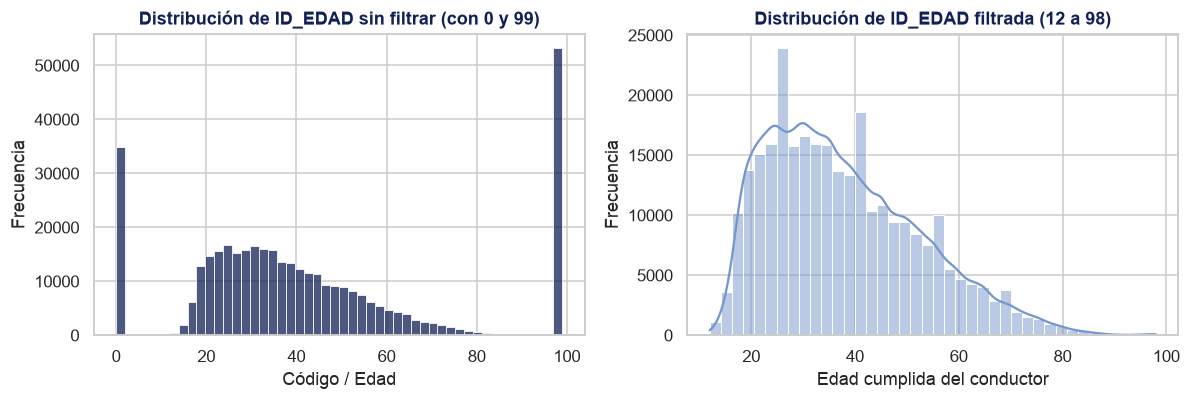

In [11]:
# Visualización del impacto de los códigos especiales
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Panel izquierdo: Sin filtrar
sns.histplot(accidentes["ID_EDAD"], bins=50, color=AZUL_OSCURO, ax=axes[0])
axes[0].set_title("Distribución de ID_EDAD sin filtrar (con 0 y 99)")
axes[0].set_xlabel("Código / Edad")
axes[0].set_ylabel("Frecuencia")

# Panel derecho: Edades válidas
sns.histplot(edad_filtrada, bins=40, color=AZUL, kde=True, ax=axes[1])
axes[1].set_title("Distribución de ID_EDAD filtrada (12 a 98)")
axes[1].set_xlabel("Edad cumplida del conductor")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Lectura.**
- La clasificación de gravedad (`CLASACC`) es consistente con el registro de víctimas: al considerar a todos los usuarios de la vía (conductores, pasajeros, peatones, ciclistas y terceros), no existe ningún accidente de *Sólo daños* con víctimas reportadas, ni ningún accidente *Fatal* con cero personas fallecidas. Esto confirma que en 734 accidentes fatales la persona fallecida no fue el conductor ni un peatón, sino un pasajero (679 casos) o un ciclista (127 casos), lo que resalta la alta vulnerabilidad de estos actores viales en siniestros urbanos.

- En `ID_EDAD`, el panel izquierdo muestra que los códigos `0` (fuga) y `99` (no especificado) generan dos picos artificiales que distorsionan la escala. Si no se filtran, la media resultante es 42.9 años. Al aislar las edades reales (panel derecho), se observa que la media real es de 37.9 años y la mediana pasa de 37 a 35 años, así mismo, la distribución se normaliza con un sesgo positivo natural y una mayor concentración entre los 20 y los 35 años de edad.

### Cardinalidad y codificación inconsistente

Revisamos cuántos valores distintos toma cada columna categórica y si existen discrepancias ortográficas o etiquetas duplicadas.

In [12]:
columnas_categoricas = accidentes.select_dtypes(exclude="number").columns

resumen_categoricas = pd.DataFrame({
    "Valores únicos": accidentes[columnas_categoricas].nunique(),
    "Muestra de categorías": [accidentes[col].unique()[:4].tolist() for col in columnas_categoricas]
})

print("Resumen de variables categóricas:")
print(resumen_categoricas)

print("\nFrecuencias en CAUSAACCI:")
print(accidentes["CAUSAACCI"].value_counts(normalize=True).round(4) * 100)

Resumen de variables categóricas:
           Valores únicos                              Muestra de categorías
DIASEMANA               7               [Miércoles, Jueves, Viernes, Sábado]
URBANA                  3  [Accidente en no intersección, Accidente en in...
SUBURBANA               4  [Sin accidente en esta zona, Accidente en carr...
ENTIDAD                32  [Aguascalientes, Baja California, Baja Califor...
TIPACCID               12  [Colisión con vehículo automotor, Colisión con...
CAUSAACCI               5  [Conductor, Peatón o pasajero, Falla del vehíc...
CAPAROD                 2                      [Pavimentada, No Pavimentada]
SEXO                    3                           [Hombre, Mujer, Se fugó]
ALIENTO                 3                                [Se ignora, Sí, No]
CINTURON                3                                [Se ignora, No, Sí]
CLASACC                 3                      [Sólo daños, No fatal, Fatal]

Frecuencias en CAUSAACCI:
CAUSAACCI
Condu

**Lectura.** Las variables categóricas presentan codificaciones estándar y cardinalidades bien acotadas:
- `ENTIDAD` tiene exactamente 32 valores correspondientes a las 32 entidades federativas de México.
- `CAUSAACCI` revela una asimetría contundente: el **95.6 %** de los percances son atribuidos formalmente al *Conductor*, mientras que causas asociadas a *Mala condición del camino* (1.9 %) o *Falla del vehículo* (1.1 %) tienen una representación marginal en los registros.

### Decisiones de limpieza

A partir de los hallazgos anteriores, establecemos las siguientes decisiones de preparación:
1. **Eliminar los 748 duplicados exactos** de captura detectados en el conjunto original.
2. **No se descartan registros por inconsistencia de gravedad**, ya que la clasificación `CLASACC` es 100 % consistente al contemplar a todos los usuarios de la vía.
3. **Definir límites de edad válida** (`EDAD_MINIMA_VALIDA = 12` y `EDAD_MAXIMA_VALIDA = 98`) para no sesgar los cálculos cuando se analice el perfil del conductor.
4. **Crear atributos agregados de víctimas** (`TOTAL_MUERTOS`, `TOTAL_HERIDOS` y `TOTAL_VICTIMAS`) para facilitar el análisis univariado y bivariado posterior.

In [13]:
EDAD_MINIMA_VALIDA = 12
EDAD_MAXIMA_VALIDA = 98

# 1. Descartamos los duplicados exactos del conjunto crudo
indices_duplicados = crudo[crudo.duplicated()].index
accidentes_limpios = accidentes.drop(index=indices_duplicados).copy()

# 2. Atributos auxiliares para cuantificar fallecidos, heridos y víctimas totales
accidentes_limpios["TOTAL_MUERTOS"] = accidentes_limpios[COLUMNAS_MUERTOS].sum(axis=1)
accidentes_limpios["TOTAL_HERIDOS"] = accidentes_limpios[COLUMNAS_HERIDOS].sum(axis=1)
accidentes_limpios["TOTAL_VICTIMAS"] = (
    accidentes_limpios["TOTAL_MUERTOS"] + accidentes_limpios["TOTAL_HERIDOS"]
)

print(f"Registros iniciales : {len(accidentes):,}")
print(f"Registros limpios   : {len(accidentes_limpios):,} (eliminados {len(indices_duplicados)} duplicados de captura)")

Registros iniciales : 380,391
Registros limpios   : 379,643 (eliminados 748 duplicados de captura)


A partir de este punto, el análisis exploratorio se realiza sobre `accidentes_limpios`.

---

## 2. Análisis univariado

Examinamos una por una las variables que usaremos después para conocer su distribución y valores típicos antes de cruzarlas.

### Variables numéricas

In [14]:
# Estadísticos descriptivos de la edad del conductor y de la hora del evento
edades_validas = accidentes_limpios[
    accidentes_limpios["ID_EDAD"].between(EDAD_MINIMA_VALIDA, EDAD_MAXIMA_VALIDA)
]["ID_EDAD"]

resumen_numericas = pd.DataFrame({
    "Edad del conductor (años)": edades_validas.describe(),
    "Hora del accidente (0 a 23)": accidentes_limpios["ID_HORA"].describe()
}).round(1)

resumen_numericas

,Edad del conductor (años),Hora del accidente (0 a 23)
count,292007.0,379643.0
mean,37.9,13.1
std,14.7,6.0
min,12.0,0.0
25%,26.0,9.0
50%,35.0,14.0
75%,47.0,18.0
max,98.0,23.0


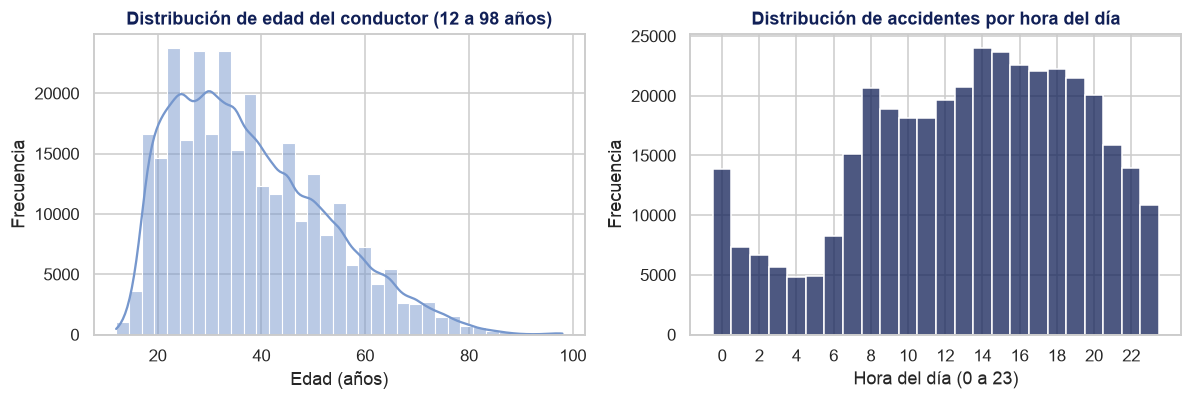

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Panel izquierdo: Distribución de edad
sns.histplot(edades_validas, bins=35, color=AZUL, kde=True, ax=axes[0])
axes[0].set_title("Distribución de edad del conductor (12 a 98 años)")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")

# Panel derecho: Distribución por hora del día
sns.histplot(accidentes_limpios["ID_HORA"], bins=24, color=AZUL_OSCURO, discrete=True, ax=axes[1])
axes[1].set_title("Distribución de accidentes por hora del día")
axes[1].set_xlabel("Hora del día (0 a 23)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

**Lectura.** La edad de los conductores tiene una mediana de 35 años y una media de 37.9 años. La mayor concentración de accidentes ocurre entre los 20 y los 35 años, y disminuye de forma constante conforme aumenta la edad. Por su parte, la distribución horaria muestra que la cantidad de accidentes comienza a subir a partir de las 7:00 de la mañana, se mantiene alta durante la tarde y alcanza su punto más alto entre las 14:00 y las 19:00 horas, coincidiendo con los horarios de mayor actividad laboral y escolar.

### Variables categóricas

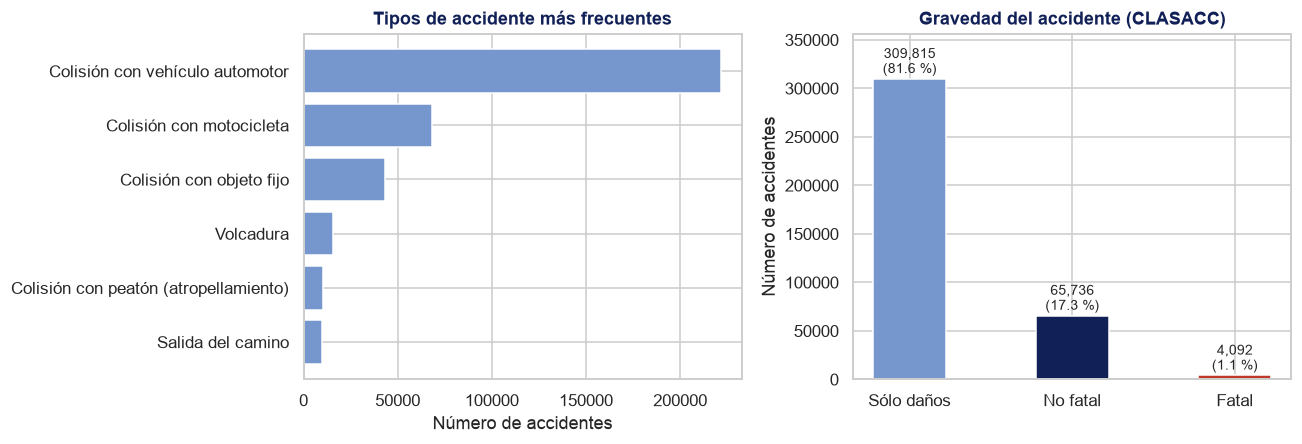

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Panel izquierdo: Tipos de accidente más comunes
top_tipos = accidentes_limpios["TIPACCID"].value_counts().head(6)
axes[0].barh(top_tipos.index[::-1], top_tipos.values[::-1], color=AZUL)
axes[0].set_title("Tipos de accidente más frecuentes")
axes[0].set_xlabel("Número de accidentes")

# Panel derecho: Distribución de la gravedad del accidente
clas_counts = accidentes_limpios["CLASACC"].value_counts()
barras = axes[1].bar(
    clas_counts.index, 
    clas_counts.values, 
    color=[AZUL, AZUL_OSCURO, ROJO], 
    width=0.45
)
axes[1].set_title("Gravedad del accidente (CLASACC)")
axes[1].set_ylabel("Número de accidentes")

for barra in barras:
    altura = barra.get_height()
    porcentaje = altura / len(accidentes_limpios) * 100
    axes[1].text(
        barra.get_x() + barra.get_width() / 2, 
        altura + 6000, 
        f"{altura:,}\n({porcentaje:.1f} %)", 
        ha="center", 
        fontsize=9
    )

axes[1].set_ylim(0, clas_counts.max() * 1.15)

plt.tight_layout()
plt.show()

**Lectura.** Más de la mitad de los percances (58.4 %) corresponden a choques entre vehículos automotores, seguidos por colisiones con motocicletas (18.0 %) y choques contra objetos fijos (11.4 %). En cuanto a la severidad, la gran mayoría de los siniestros dejan únicamente daños materiales (81.6 %), el 17.3 % deja personas lesionadas y el 1.1 % resulta en personas fallecidas.

---

## 3. Análisis bivariado

Cruzamos pares de variables para responder preguntas concretas sobre el momento en que ocurren los accidentes y los factores asociados a su gravedad.

**Pregunta 1.** ¿En qué horarios se concentran los accidentes fatales en comparación con los de sólo daños?

Nos interesa saber si los percances mortales siguen el mismo horario de tráfico habitual o si se desplazan hacia horas con menor visibilidad y mayor velocidad.

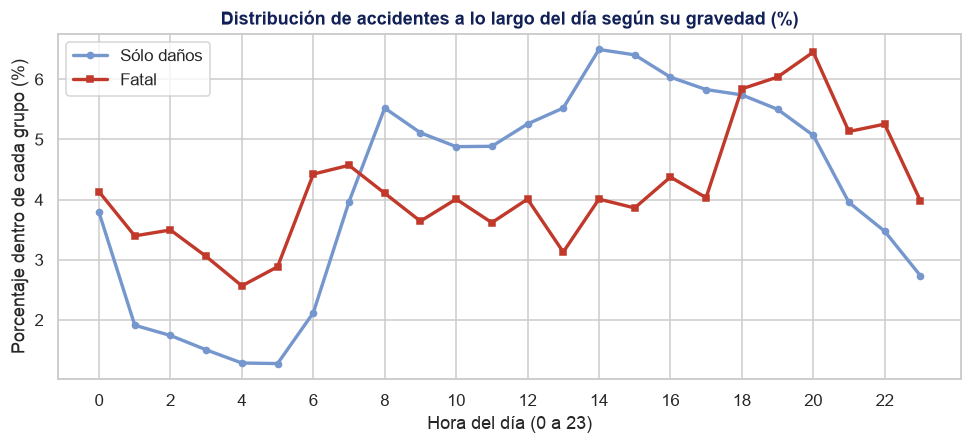

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.2))

# Calculamos el porcentaje de accidentes por hora dentro de cada nivel de gravedad
tabla_hora = accidentes_limpios.groupby(["ID_HORA", "CLASACC"]).size().unstack()
pct_hora = tabla_hora.div(tabla_hora.sum(axis=0), axis=1) * 100

ax.plot(pct_hora.index, pct_hora["Sólo daños"], label="Sólo daños", color=AZUL, linewidth=2.2, marker="o", markersize=4)
ax.plot(pct_hora.index, pct_hora["Fatal"], label="Fatal", color=ROJO, linewidth=2.2, marker="s", markersize=4)

ax.set_title("Distribución de accidentes a lo largo del día según su gravedad (%)")
ax.set_xlabel("Hora del día (0 a 23)")
ax.set_ylabel("Porcentaje dentro de cada grupo (%)")
ax.set_xticks(range(0, 24, 2))
ax.legend()

plt.tight_layout()
plt.show()

**Lectura.** Los accidentes de sólo daños tienen su punto más alto a media tarde (entre las 14:00 y las 16:00 horas), coincidiendo con las horas de mayor circulación vehicular. En cambio, los accidentes fatales se desplazan hacia la noche y la madrugada: alcanzan su nivel más alto entre las 18:00 y las 21:00 horas, y durante la madrugada (de 1:00 a 5:00 h) su proporción duplica a la de los accidentes leves, probablemente por factores como exceso de velocidad y menor iluminación.

**Pregunta 2.** ¿Cómo influye la condición de aliento del conductor en la gravedad del accidente?

Comparamos el desenlace del percance en los casos donde la autoridad registró aliento alcohólico frente a los que no.

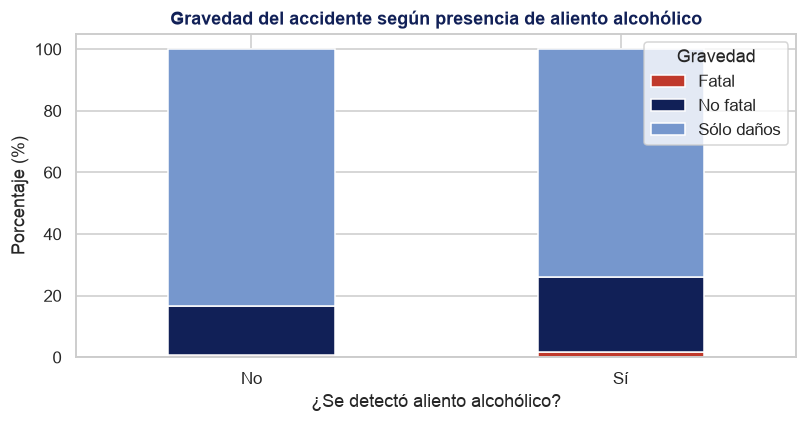

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4))

# Filtramos solo los registros con respuesta definida (Sí / No)
aliento_val = accidentes_limpios[accidentes_limpios["ALIENTO"].isin(["No", "Sí"])]
pct_aliento = pd.crosstab(aliento_val["ALIENTO"], aliento_val["CLASACC"], normalize="index") * 100

pct_aliento[["Fatal", "No fatal", "Sólo daños"]].plot(
    kind="bar", 
    stacked=True, 
    color=[ROJO, AZUL_OSCURO, AZUL], 
    ax=ax, 
    width=0.45
)

ax.set_title("Gravedad del accidente según presencia de aliento alcohólico")
ax.set_xlabel("¿Se detectó aliento alcohólico?")
ax.set_ylabel("Porcentaje (%)")
ax.set_xticklabels(["No", "Sí"], rotation=0)
ax.legend(title="Gravedad", loc="upper right")

plt.tight_layout()
plt.show()

**Lectura.** Cuando se detecta aliento alcohólico en el conductor, la proporción de accidentes fatales pasa de 0.7 % a 1.6 % (más del doble) y los accidentes con personas lesionadas suben de 16.0 % a 24.4 %. Aunque los choques con alcohol son menores en cantidad absoluta, su probabilidad de causar víctimas es más alta.

**Pregunta 3.** ¿Qué tipos de accidente tienen el mayor riesgo de dejar víctimas?

Analizamos qué porcentaje de percances resulta en personas lesionadas o fallecidas según el tipo de evento.

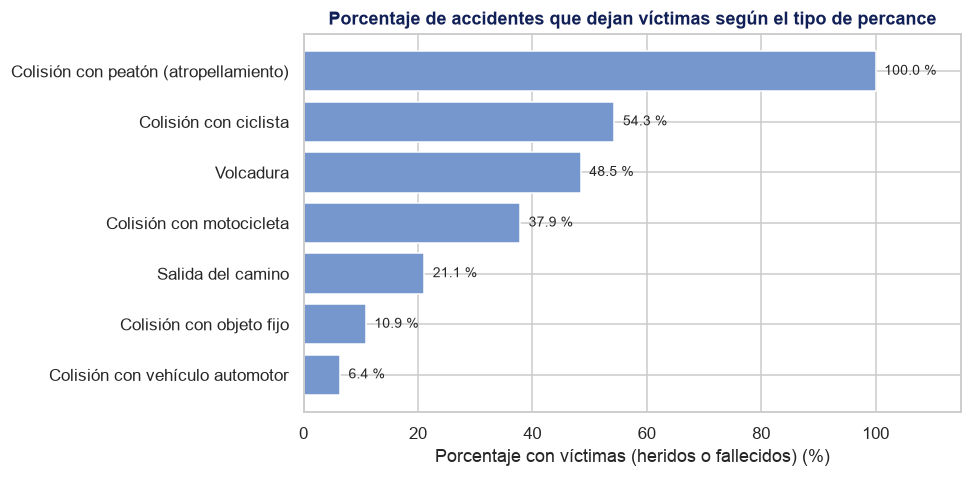

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))

principales_tipos = [
    "Colisión con peatón (atropellamiento)", 
    "Colisión con ciclista", 
    "Volcadura", 
    "Colisión con motocicleta", 
    "Salida del camino", 
    "Colisión con objeto fijo", 
    "Colisión con vehículo automotor"
]

sub_tipos = accidentes_limpios[accidentes_limpios["TIPACCID"].isin(principales_tipos)]
pct_vic = sub_tipos.groupby("TIPACCID")["TOTAL_VICTIMAS"].apply(
    lambda x: (x > 0).mean() * 100
).loc[principales_tipos[::-1]]

barras = ax.barh(pct_vic.index, pct_vic.values, color=AZUL)
ax.set_title("Porcentaje de accidentes que dejan víctimas según el tipo de percance")
ax.set_xlabel("Porcentaje con víctimas (heridos o fallecidos) (%)")
ax.set_xlim(0, 115)

for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho + 1.5, barra.get_y() + barra.get_height() / 2, f"{ancho:.1f} %", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Lectura.** El tipo de percance determina fuertemente si habrá víctimas. En choques entre vehículos automotores, solo el 6.4 % deja personas heridas o fallecidas, ya que la estructura del vehículo absorbe la mayor parte del golpe. En contraste, en los atropellamientos el 100 % de los eventos deja víctimas al no haber ninguna protección física, mientras que en ciclistas es el 54.3 %, en volcaduras el 48.5 % y en motocicletas el 37.9 %.

#### Detalle adicional: Lesionados vs. Fallecidos

Al observar la gráfica anterior, surgió la duda sobre cómo se reparte ese riesgo entre personas que resultan lesionadas y aquellas que lamentablemente fallecen. Por ello, decidí desglosar ese porcentaje para distinguir la tasa de personas heridas (*No fatal*) frente a la de personas fallecidas (*Fatal*).

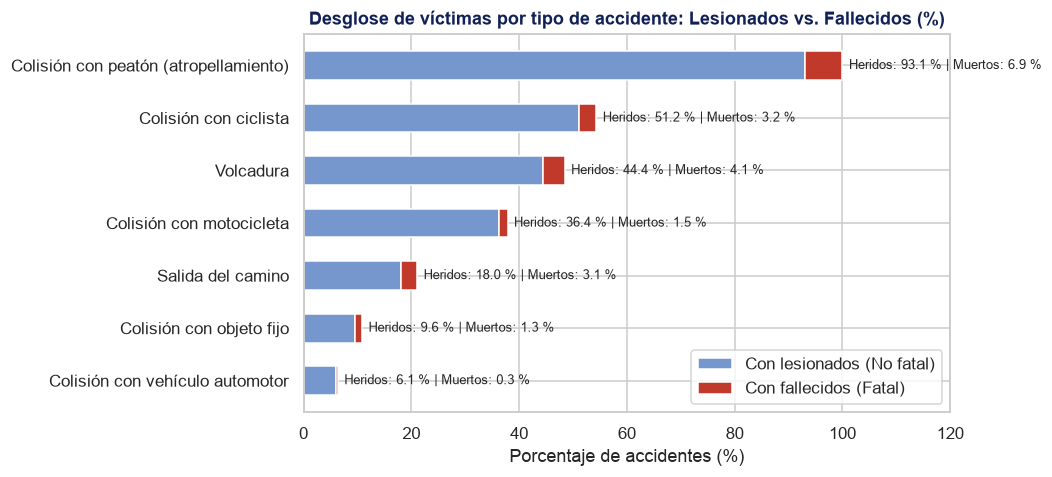

In [20]:
# Desglose de porcentaje de lesionados frente a fallecidos por tipo de accidente
sub_tipos = accidentes_limpios[accidentes_limpios["TIPACCID"].isin(principales_tipos)]
desglose_gravedad = sub_tipos.groupby("TIPACCID").apply(
    lambda g: pd.Series({
        "Lesionados": (g["CLASACC"] == "No fatal").mean() * 100,
        "Fallecidos": (g["CLASACC"] == "Fatal").mean() * 100
    })
).loc[principales_tipos[::-1]]

fig, ax = plt.subplots(figsize=(9.5, 4.5))

ax.barh(
    desglose_gravedad.index, 
    desglose_gravedad["Lesionados"], 
    label="Con lesionados (No fatal)", 
    color=AZUL, 
    height=0.55
)
ax.barh(
    desglose_gravedad.index, 
    desglose_gravedad["Fallecidos"], 
    left=desglose_gravedad["Lesionados"], 
    label="Con fallecidos (Fatal)", 
    color=ROJO, 
    height=0.55
)

ax.set_title("Desglose de víctimas por tipo de accidente: Lesionados vs. Fallecidos (%)")
ax.set_xlabel("Porcentaje de accidentes (%)")
ax.set_xlim(0, 120)
ax.legend(loc="lower right")

for i, (tipo, fila) in enumerate(desglose_gravedad.iterrows()):
    total_pct = fila["Lesionados"] + fila["Fallecidos"]
    ax.text(
        total_pct + 1.2, 
        i, 
        f"Heridos: {fila['Lesionados']:.1f} % | Muertos: {fila['Fallecidos']:.1f} %", 
        va="center", 
        fontsize=8.5
    )

plt.tight_layout()
plt.show()

**Lectura.** El desglose muestra que no todos los percances con víctimas tienen la misma gravedad. El atropellamiento a peatones es por mucho el siniestro más letal: casi el 7 % de los eventos termina en la muerte de la persona, seguido por las volcaduras con un 4.1 % de fatalidad. En cambio, en los choques entre vehículos automotores la probabilidad de muerte es sumamente baja (menos del 0.3 %), concentrándose casi exclusivamente en lesiones leves o daños materiales.

---

## 4. Análisis multivariado

Combinamos la hora del día, el día de la semana y la gravedad del percance en una sola vista para contrastar dos dimensiones: en qué momentos ocurre la mayor cantidad de choques frente a en qué momentos son más letales.

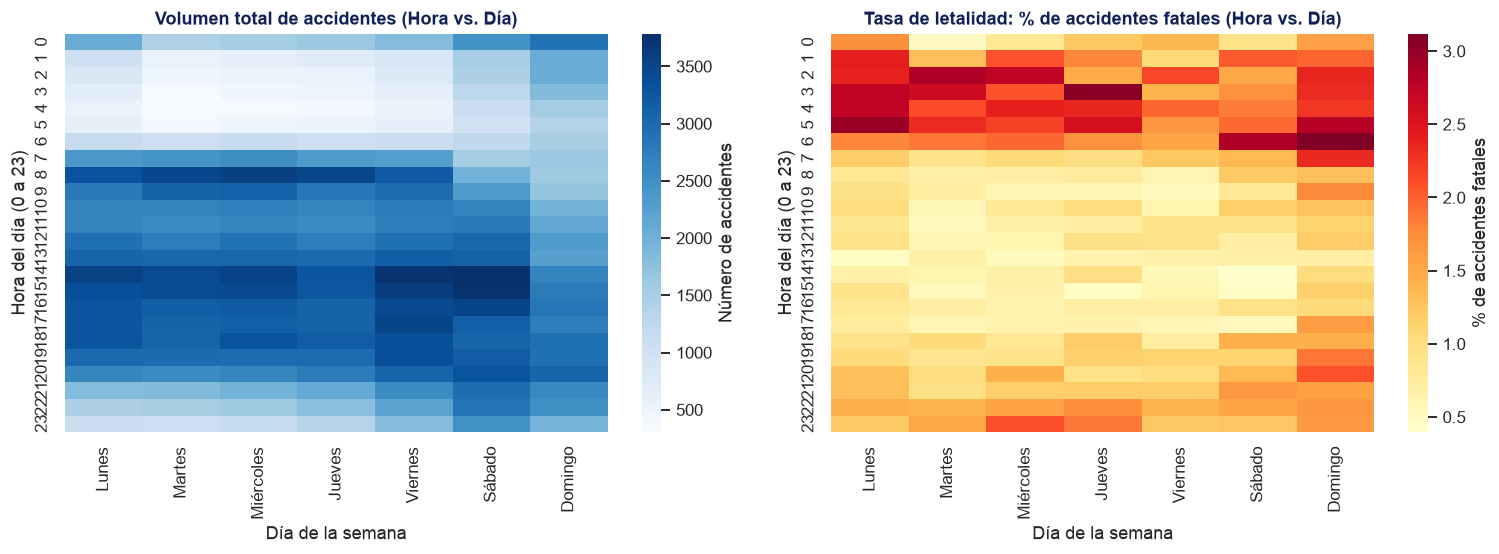

In [21]:
dias_orden = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# Matriz 1: Cantidad total de accidentes
pivote_total = accidentes_limpios.pivot_table(
    index="ID_HORA", 
    columns="DIASEMANA", 
    values="CLASACC", 
    aggfunc="count"
)[dias_orden]

# Matriz 2: Porcentaje de accidentes fatales
pivote_fatal = accidentes_limpios.pivot_table(
    index="ID_HORA", 
    columns="DIASEMANA", 
    values="CLASACC", 
    aggfunc=lambda x: (x == "Fatal").mean() * 100
)[dias_orden]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Panel izquierdo: Volumen total
sns.heatmap(pivote_total, cmap="Blues", ax=axes[0], cbar_kws={"label": "Número de accidentes"})
axes[0].set_title("Volumen total de accidentes (Hora vs. Día)")
axes[0].set_xlabel("Día de la semana")
axes[0].set_ylabel("Hora del día (0 a 23)")

# Panel derecho: Tasa de letalidad (%)
sns.heatmap(pivote_fatal, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "% de accidentes fatales"})
axes[1].set_title("Tasa de letalidad: % de accidentes fatales (Hora vs. Día)")
axes[1].set_xlabel("Día de la semana")
axes[1].set_ylabel("Hora del día (0 a 23)")

plt.tight_layout()
plt.show()

**Lectura.** El contraste entre ambos paneles muestra una diferencia clara entre volumen y gravedad. La cantidad total de percances (panel izquierdo) se concentra en las tardes de lunes a sábado, principalmente entre las 14:00 y las 19:00 horas, lo cual coincide con los horarios de mayor tráfico urbano. Es interesante destacar cómo también el número de percances es alto de lunes a viernes a las 8:00 h, lo que coincide con el horario en que las personas se desplazan a escuelas y trabajos.

La tasa de letalidad (panel derecho) se invierte: los porcentajes más altos de accidentes mortales ocurren en las madrugadas (de 1:00 a 6:00 h), especialmente los fines de semana, donde la velocidad y la menor presencia de tráfico aumentan la gravedad del impacto.

---

## 5. Hallazgos y trabajo pendiente

Sintetizamos los aprendizajes principales del análisis exploratorio, las preguntas que abre el conjunto y los aspectos de calidad de datos que deberán atenderse antes de cualquier modelo posterior.

### Hallazgos

1. **Diferencia entre volumen y letalidad:**  
   La gran mayoría de los accidentes ocurren en las tardes de lunes a sábado (entre las 14:00 y las 19:00 horas), coincidiendo con las horas de mayor tráfico. Sin embargo, los accidentes fatales se concentran en las noches y madrugadas de fin de semana (de 1:00 a 6:00 horas), donde la probabilidad de que un accidente resulte mortal llega a duplicarse.
2. **Vulnerabilidad de peatones y ciclistas:**  
   En los choques entre vehículos automotores, solo el 6.4% deja víctimas y apenas el 0.3% causa muertes. En cambio, en los atropellamientos a peatones el 100% de los eventos deja víctimas y casi el 7% termina en fallecimiento (una letalidad 25 veces mayor que en choques de autos). Las volcaduras también presentan una tasa alta de mortalidad (4.1%).
3. **El impacto del alcohol en la gravedad del percance:**  
   Cuando se registra aliento alcohólico en el conductor, la proporción de accidentes fatales pasa de 0.7% a 1.6% (más del doble) y los percances con personas lesionadas aumentan de 16.0% a 24.4%. Aunque representan una cantidad menor en el total de choques, su riesgo de causar víctimas es notablemente más alto.

---

### Preguntas que abre el conjunto

1. ¿En qué tipos de calles o zonas urbanas se concentran los atropellamientos nocturnos, y qué adecuaciones (iluminación, pasos peatonales con semáforo o reductores de velocidad) tendrían mayor impacto para reducirlos?
2. Dado que las horas con mayor tasa de muertes ocurren entre la 1:00 y las 6:00 de la mañana en fines de semana, ¿en qué medida operativos de alcoholimetría y radares de velocidad en esos horarios específicos ayudarían a disminuir la mortalidad vial?
3. ¿Qué características comparten los accidentes donde el conductor se da a la fuga (`ID_EDAD = 0`, que representa el 9.2 % de los casos)? ¿Ocurren con mayor frecuencia de noche o en atropellamientos?

---

### Problemas que habría que corregir antes de cualquier análisis posterior

1. El 77.4 % de los registros no especifica el uso de cinturón de seguridad y el 35.4 % no reporta la condición de alcoholemia. Para construir modelos predictivos, estas variables no pueden usarse directamente sin una estrategia previa para manejar esa falta de información.
2. Casi una cuarta parte de los registros (23.2 %) no tiene una edad real del conductor, sino códigos especiales (0 para conductores fugados y 99 para edades no especificadas). Cualquier modelo estadístico o de aprendizaje automático debe tratar estos casos como categorías independientes y no como números continuos para no sesgar los cálculos.
3. Aunque representan una fracción pequeña del total (748 de 380 mil registros), deben removerse permanentemente en la etapa de preprocesamiento para evitar contar dos veces el mismo percance.

---
### Declaración sobre el uso de IA Generativa

Este notebook fue laborado con apoyo de modelos de lenguaje basados en IA (Gemini / Antigravity) como herramientas de apoyo para la depuración de código y la revisión de textos. El razonamiento analítico, el planteamiento metodológico, la interpretación de resultados y la redacción final de los hallazgos son responsabilidad del autor.

---

### Referencias

1. **INEGI (2026).** *Estadística de Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS 2025), cifras definitivas*. Instituto Nacional de Estadística y Geografía. [https://www.inegi.org.mx/programas/accidentes/](https://www.inegi.org.mx/programas/accidentes/)
2. **INEGI (2026).** *Metadatos y Diccionario de Datos de ATUS 1997-2025*. [https://www.inegi.org.mx/rnm/index.php/catalog/1115/data-dictionary](https://www.inegi.org.mx/rnm/index.php/catalog/1115/data-dictionary)
3. **MIT Communication Lab (2021).** *Coding and Comment Style Guide*. Broad Institute / MIT CommKit. [https://mitcommlab.mit.edu/broad/commkit/coding-and-comment-style/](https://mitcommlab.mit.edu/broad/commkit/coding-and-comment-style/)
4. **López Nava, I. H. (2026).** *Diapositivas y notas de clase de la Sesión 4: Visualización*. Posgrado en Ciencias de la Computación, CICESE.
5. **Waskom, M. L. (2021).** *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021.